In [26]:
!zip -r asset_allocation.zip asset_allocation/

  adding: asset_allocation/ (stored 0%)
  adding: asset_allocation/dp_v2_solver.py (deflated 69%)
  adding: asset_allocation/utils.py (deflated 65%)
  adding: asset_allocation/a2c_solver.py (deflated 57%)
  adding: asset_allocation/__init__.py (deflated 53%)
  adding: asset_allocation/adp_mc_solver.py (deflated 67%)
  adding: asset_allocation/__pycache__/ (stored 0%)
  adding: asset_allocation/__pycache__/environment.cpython-313.pyc (deflated 50%)
  adding: asset_allocation/__pycache__/config.cpython-312.pyc (deflated 52%)
  adding: asset_allocation/__pycache__/evaluation.cpython-313.pyc (deflated 50%)
  adding: asset_allocation/__pycache__/ppo_solver.cpython-313.pyc (deflated 42%)
  adding: asset_allocation/__pycache__/environment.cpython-312.pyc (deflated 50%)
  adding: asset_allocation/__pycache__/dp_v2_solver.cpython-313.pyc (deflated 50%)
  adding: asset_allocation/__pycache__/__init__.cpython-313.pyc (deflated 47%)
  adding: asset_allocation/__pycache__/run_single.cpython-313.pyc

# Multi-Asset Portfolio Allocation via Dynamic Programming and RL

This notebook demonstrates several approaches to solving a finite-horizon portfolio allocation problem:

| Method | Type | Expectations | Action Space |
|--------|------|-------------|-------------|
| **Tabular DP** | Exact DP | Gauss-Hermite quadrature | Feasible deltas on grid |
| **ADP-Hermite** | Approximate DP (NN) | Gauss-Hermite quadrature | Feasible deltas |
| **ADP-MC** | Approximate DP (NN) | Monte Carlo | Feasible deltas |
| **DP v2** | Approximate DP (NN) | Monte Carlo | Normalized [-1,1] grid |
| **PPO** | Model-free RL | Learned from rollouts | Continuous [-1,1] |
| **A2C** | Model-free RL | Actor-Critic | Continuous [-1,1] |
| **Hold** | Baseline | N/A | Zero action |
| **Heuristic** | Baseline | N/A | Sharpe-score proportional |

## 1. Mathematical Formulation

### 1.1 The MDP

We model portfolio allocation as a **finite-horizon Markov Decision Process** $(\mathcal{S}, \mathcal{A}, P, R, T)$:

- **State** at time $t$: $s_t = (W_t, p_t^{(0)}, p_t^{(1)}, \ldots, p_t^{(n)})$ where $W_t$ is wealth and $p_t^{(k)}$ is the portfolio weight of asset $k$ ($k=0$ is cash).

- **Action**: $a_t = (\delta_1, \ldots, \delta_n)$ where $\delta_k$ is the change in weight for risky asset $k$. Cash adjustment is implied: $\delta_0 = -\sum_{k=1}^n \delta_k$.

- **Transition**: Given rebalanced weights $\tilde{p}$, asset returns $R_k \sim \mathcal{N}(\mu_k, \sigma_k^2)$ independently, the portfolio return is:
$$R_\text{port} = \tilde{p}^{(0)} \cdot r + \sum_{k=1}^n \tilde{p}^{(k)} \cdot R_k$$
$$W_{t+1} = W_t \cdot (1 + R_\text{port})$$
After returns, weights drift: $p_{t+1}^{(k)} = \tilde{p}^{(k)} \cdot (1 + R_k) / (1 + R_\text{port})$.

- **Reward**: $r_t = 0$ for $t < T$, $r_T = u(W_T)$ at terminal time.

### 1.2 CARA Utility

We use **Constant Absolute Risk Aversion (CARA)** utility:
$$u(W) = \frac{1 - e^{-A \cdot W}}{A}$$
where $A > 0$ is the risk-aversion coefficient.

### 1.3 Constraints

- **Turnover**: $\frac{1}{2}\left(|\delta_0| + \sum_{k=1}^n |\delta_k|\right) \leq \tau_{\max}$
- **Long-only**: $p^{(k)} \geq 0 \; \forall k$
- **Leverage** (if short-selling): $|p^{(0)}| + \sum_{k=1}^n |p^{(k)}| \leq L$

### 1.4 Bellman Equation

$$V_T(s) = u(W_T)$$
$$V_t(s) = \max_{a \in \mathcal{A}(s)} \; \mathbb{E}\left[ V_{t+1}(s') \mid s, a \right]$$

### 1.5 Gauss-Hermite Quadrature

For expectations over Gaussian random variables, Gauss-Hermite quadrature gives **exact** results for polynomial integrands:

$$\int f(x) \cdot \frac{1}{\sqrt{2\pi}\sigma} e^{-(x-\mu)^2/2\sigma^2} dx \approx \sum_{q=1}^Q \frac{w_q}{\sqrt{\pi}} \cdot f(\sqrt{2}\sigma \cdot x_q + \mu)$$

where $(x_q, w_q)$ are the Hermite quadrature nodes and weights from `scipy.special.roots_hermite`.

For $n$ independent assets with $Q_1$ points each, the joint quadrature has $Q = Q_1^n$ points. With $Q_1 = 5, n = 3$: $Q = 125$ integration points.

### 1.6 Monte-Carlo
For expectations over Gaussian random variables, **Monte Carlo sampling** approximates the integral by averaging over random draws:

$$
\int f(x)\,\mathcal{N}(x;\mu,\sigma^2)\,dx \;\approx\; \frac{1}{M}\sum_{m=1}^M f(x^{(m)}), \quad x^{(m)} \sim \mathcal{N}(\mu,\sigma^2)
$$

Equivalently:
$$
x^{(m)} = \mu + \sigma z^{(m)}, \quad z^{(m)} \sim \mathcal{N}(0,1)
$$

For $n$ independent assets:
$$
\mathbb{E}[f(x)] \approx \frac{1}{M}\sum_{m=1}^M f(x^{(m)}), \quad x^{(m)} \in \mathbb{R}^n
$$

Monte Carlo is **not exact**, but converges at rate $\mathcal{O}(1/\sqrt{M})$ and scales linearly with dimension.

## 2. Setup

### For Google Colab:

1. Upload the `asset_allocation/` folder to `/content/asset_allocation/`
2. Run the setup cell below
3. Then run all cells top-to-bottom

In [3]:
# --- Colab setup (skip if local) ---
import os, sys, zipfile

if 'COLAB_GPU' in os.environ or 'COLAB_RELEASE_TAG' in os.environ:
    %pip install -q stable-baselines3

    # unzip your package if needed
    zip_path = "/content/asset_allocation.zip"
    if os.path.exists(zip_path) and not os.path.exists("/content/asset_allocation"):
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall("/content")

    if "/content" not in sys.path:
        sys.path.insert(0, "/content")

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from asset_allocation.config import SCENARIOS, ScenarioConfig
from asset_allocation.environment import PortfolioEnv
from asset_allocation.baselines import hold_policy, heuristic_policy
from asset_allocation.evaluation import (
    evaluate_policy, rollout_episode, generate_shared_returns, format_result
)
from asset_allocation.plotting import (
    plot_wealth_progression, plot_utility_comparison, plot_wealth_boxplot,
    plot_portfolio_weights, plot_rebalancing_actions,
    plot_economic_intuition, plot_decision_anatomy, plot_all
)

print("Imports OK")

Imports OK


## 3. Scenario Configuration

We use the `colab_demo` scenario: 3 risky assets, T=5 periods, all assets have positive excess returns.

In [5]:
config = SCENARIOS['colab_demo']
print(config.summary())
print(f"Assets: a_k={config.a_k}, s_k={config.s_k}")
print(f"Initial portfolio: {config.p_init}")
print(f"Constraints: turnover={config.max_turnover}, action_max={config.action_max}")

Colab Demo: n=3, T=5, r=0.02, A=0.7, long-only, lev=1.0
Assets: a_k=[0.08, 0.1, 0.12], s_k=[0.02, 0.025, 0.03]
Initial portfolio: [0.7, 0.1, 0.1, 0.1]
Constraints: turnover=0.1, action_max=0.1


## 4. Train / Load All Methods

In [6]:
# 4.1 Baselines (no training needed)
policy_fns = {
    'hold': hold_policy,
    'heuristic': heuristic_policy,
}
print("Baselines ready")

Baselines ready


### 4.2 Tabular DP (Exact Solution)

Exact backward induction on a discretized grid. This is the gold standard for small problems but suffers from the curse of dimensionality: grid size is $O(W \cdot P^n)$ where $W$ is wealth grid size and $P$ is the proportion grid size per asset.

With `prop_step=0.20` and `n=3`: $6^3 = 216$ proportion combos $\times$ 20 wealth points = 4,320 states per time step.

In [ ]:
from asset_allocation.tabular_solver import solve as tabular_solve, get_policy_fn as tabular_policy

tab_state = tabular_solve(config)
policy_fns['tabular'] = tabular_policy(tab_state)

[Tabular DP] n=3, T=5, r=0.03, A=0.7
  Wealth: 20 pts, Prop: 11 pts, Combos: 1331, Actions: 309, Quad: 125

Backward Induction (Tabular)
  t=4: 11,120 states, 147.7s
  t=3: 11,120 states, 144.2s
  t=2: 11,120 states, 144.2s
  t=1: 11,120 states, 146.4s
  t=0: 11,120 states, 143.8s
Total: 726.3s


### 4.3 ADP-Hermite

Replaces the grid-based value function with a neural network, but keeps exact Gauss-Hermite expectations. This scales better to larger state spaces (no curse of dimensionality in the value function) while maintaining zero MC noise.

**Training**: At each backward step $t$, sample training states, compute Bellman targets via quadrature, and fit a 2-layer MLP.

In [7]:
from asset_allocation.adp_hermite_solver import solve as hermite_solve, get_policy_fn as hermite_policy

herm_state = hermite_solve(config)
policy_fns['adp_hermite'] = hermite_policy(herm_state)

  [adp_hermite] Loading from cache: adp_hermite_colab_demo_ee82cf873075.pt


### 4.4 ADP-MC

Same NN value function as ADP-Hermite, but expectations are computed via Monte Carlo sampling of returns. More flexible (works with any return distribution) but noisier.

In [11]:
from asset_allocation.adp_mc_solver import solve as mc_solve, get_policy_fn as mc_policy

mc_state = mc_solve(config)
policy_fns['adp_mc'] = mc_policy(mc_state)

  [adp_mc] Loading from cache: adp_mc_colab_demo_6fc793f4dce7.pt


### 4.5 DP v2 (MC + Normalized Actions)

Alternative ADP with actions on a normalized $[-1, 1]^n$ grid. An alternative ADP approach where actions are a grid in $[-1, 1]^n$ mapped to deltas via `action_max`. Simpler parametrization but less sample-efficient because many grid points may be infeasible after projection.

This is a bad method. Later you can see that it often produces non-optimal policy. Good example: short the loser (long_short_mixed).

In [10]:
from asset_allocation.dp_v2_solver import solve as dpv2_solve, get_policy_fn as dpv2_policy

dpv2_state = dpv2_solve(config)
policy_fns['dp_v2'] = dpv2_policy(dpv2_state)

  [dp_v2] Loading from cache: dp_v2_colab_demo_241fc34102db.pt


### 4.6 PPO (Model-Free RL)

Proximal Policy Optimization from stable-baselines3. Does **not** exploit the known Gaussian return model or the finite-horizon structure. More sample-inefficient but robust to model misspecification.

Training uses `gamma=1.0` (no discounting) since only the terminal reward matters.

In [9]:
from asset_allocation.ppo_solver import solve as ppo_solve, get_policy_fn as ppo_policy

ppo_state = ppo_solve(config)
policy_fns['ppo'] = ppo_policy(ppo_state)

  [ppo] Loading from cache: ppo_colab_demo_2244bc3935af.zip
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


### 4.7 A2C (Model-Free RL)

Advantage Actor-Critic from stable-baselines3. Synchronous updates, simpler than PPO but often competitive.

In [8]:
from asset_allocation.a2c_solver import solve as a2c_solve, get_policy_fn as a2c_policy

a2c_state = a2c_solve(config)
policy_fns['a2c'] = a2c_policy(a2c_state)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


[A2C] n=3, T=5, A=0.7, timesteps=200000
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


------------------------------------
| rollout/              |          |
|    ep_len_mean        | 5        |
|    ep_rew_mean        | 0.829    |
| time/                 |          |
|    fps                | 637      |
|    iterations         | 100      |
|    time_elapsed       | 0        |
|    total_timesteps    | 500      |
| train/                |          |
|    entropy_loss       | -4.23    |
|    explained_variance | nan      |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | 0.0226   |
|    std                | 0.991    |
|    value_loss         | 0.000209 |
------------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Streaming output truncated to the last 5000 lines.
|    iterations         | 12300    |
|    time_elapsed       | 94       |
|    total_timesteps    | 61500    |
| train/                |          |
|    entropy_loss       | -4.17    |
|    explained_variance | nan      |
|    learning_rate      | 0.0007   |
|    n_updates          | 12299    |
|    policy_loss        | 0.0205   |
|    std                | 0.972    |
|    value_loss         | 0.000458 |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 5        |
|    ep_rew_mean        | 0.887    |
| time/                 |          |
|    fps                | 652      |
|    iterations         | 12400    |
|    time_elapsed       | 94       |
|    total_timesteps    | 62000    |
| train/                |          |
|    entropy_loss       | -4.19    |
|    explained_variance | nan      |
|    learning_rate      | 0.0007   |
|    n_updates          

## 5. Core Comparison

Evaluate all methods on the same shared return paths for fair comparison.

In [12]:
shared = generate_shared_returns(config)

results = {}
for name, pfn in policy_fns.items():
    env = PortfolioEnv(config)
    results[name] = evaluate_policy(
        env, pfn, n_episodes=config.n_eval_episodes,
        seed=config.seed, shared_returns=shared
    )
    print(format_result(results[name], name))

  hold                    utility=0.83545 +/- 0.03736  wealth=1.25865 +/- 0.09133
  heuristic               utility=0.89367 +/- 0.06825  wealth=1.41536 +/- 0.18718
  adp_hermite             utility=0.90208 +/- 0.08602  wealth=1.44587 +/- 0.24176
  a2c                     utility=0.89232 +/- 0.06733  wealth=1.41137 +/- 0.18412
  ppo                     utility=0.89715 +/- 0.07178  wealth=1.42616 +/- 0.19854
  dp_v2                   utility=0.89812 +/- 0.08893  wealth=1.43657 +/- 0.25131
  adp_mc                  utility=0.90108 +/- 0.08243  wealth=1.44140 +/- 0.23040


  Saved: utility_colab_demo.png


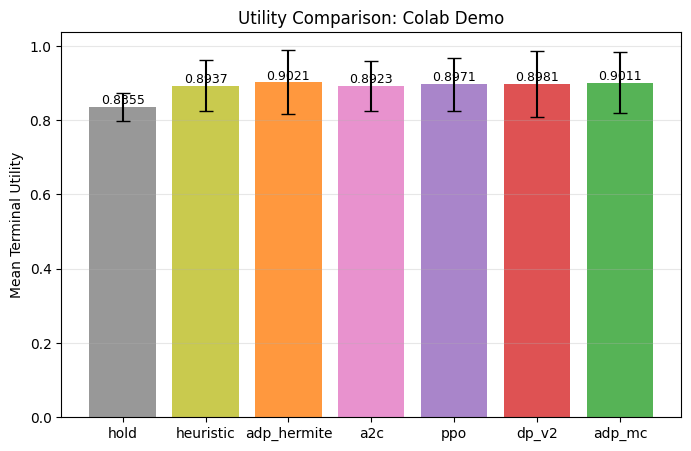

  Saved: wealth_colab_demo.png


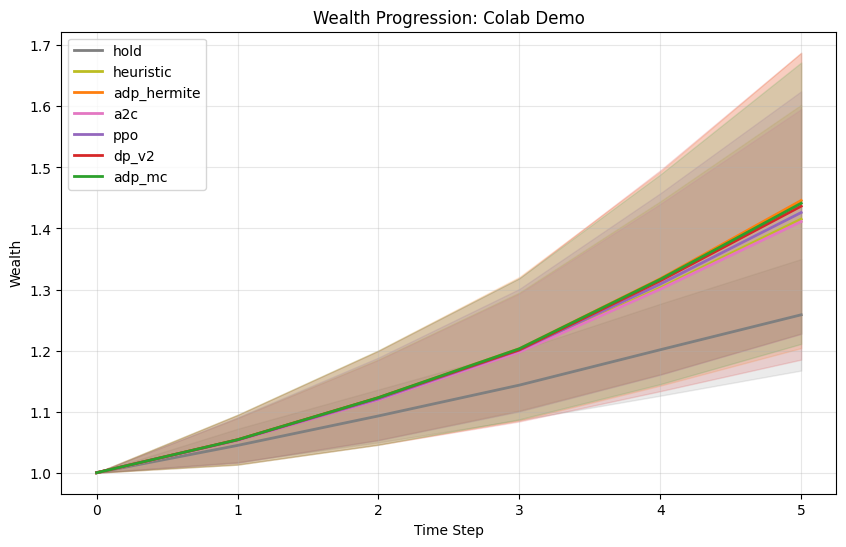

/content/asset_allocation/plotting.py:124: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=names, patch_artist=True, showfliers=False)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Saved: wealth_box_colab_demo.png


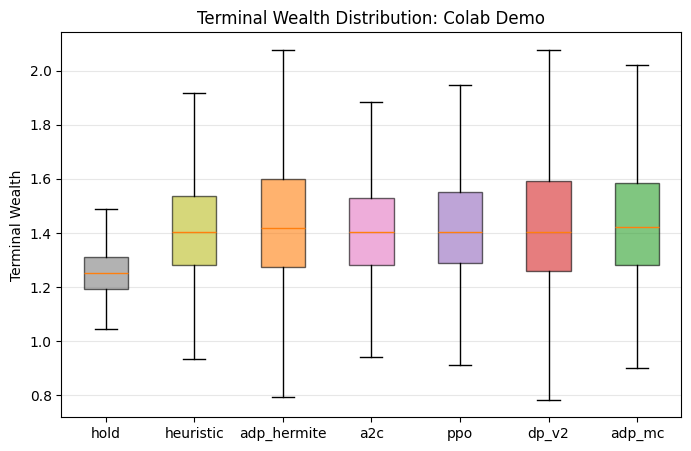

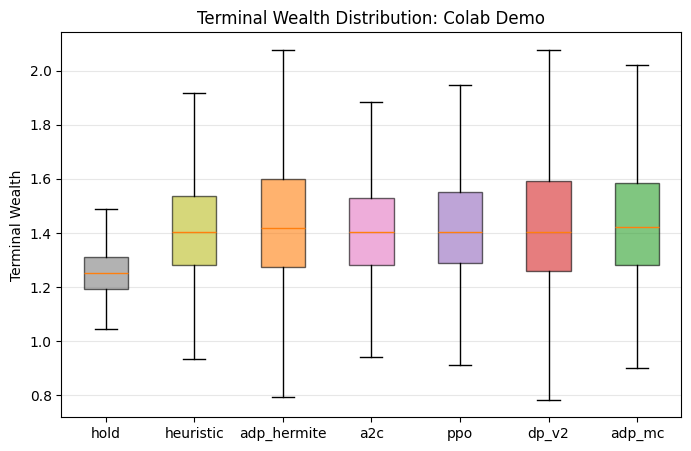

In [13]:
# Terminal utility comparison and wealth progression
plot_utility_comparison(results, config.name)
plot_wealth_progression(results, config.name)
plot_wealth_boxplot(results, config.name)

### 5.1 Portfolio Weights Over Time

Average portfolio weights at each timestep across episodes. One subplot per asset.

  Saved: weights_colab_demo.png


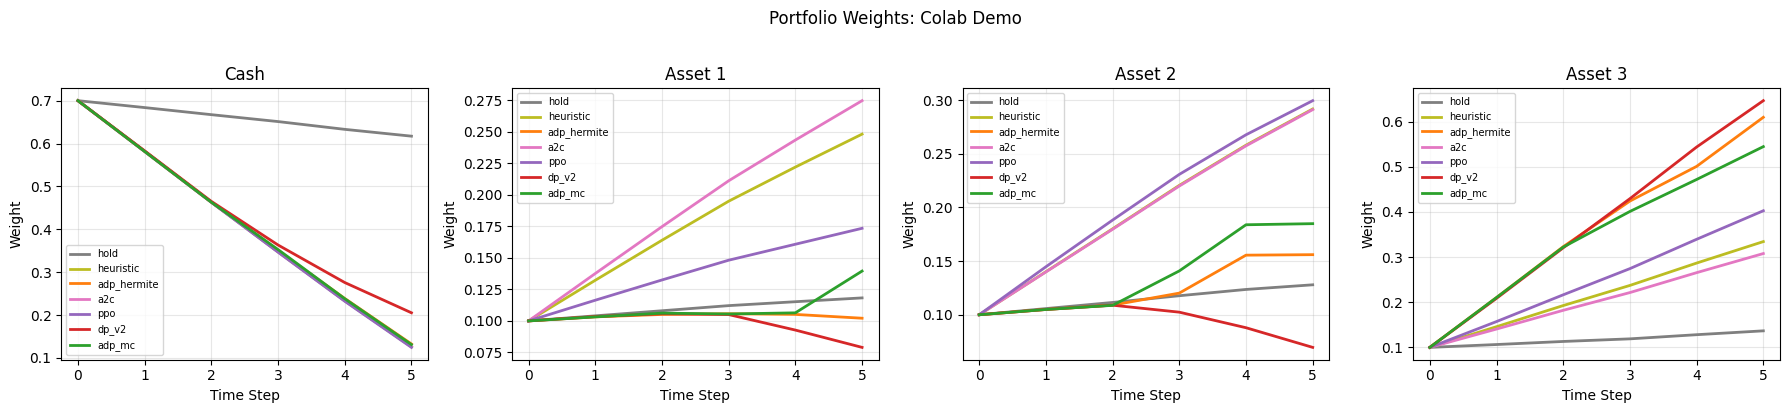

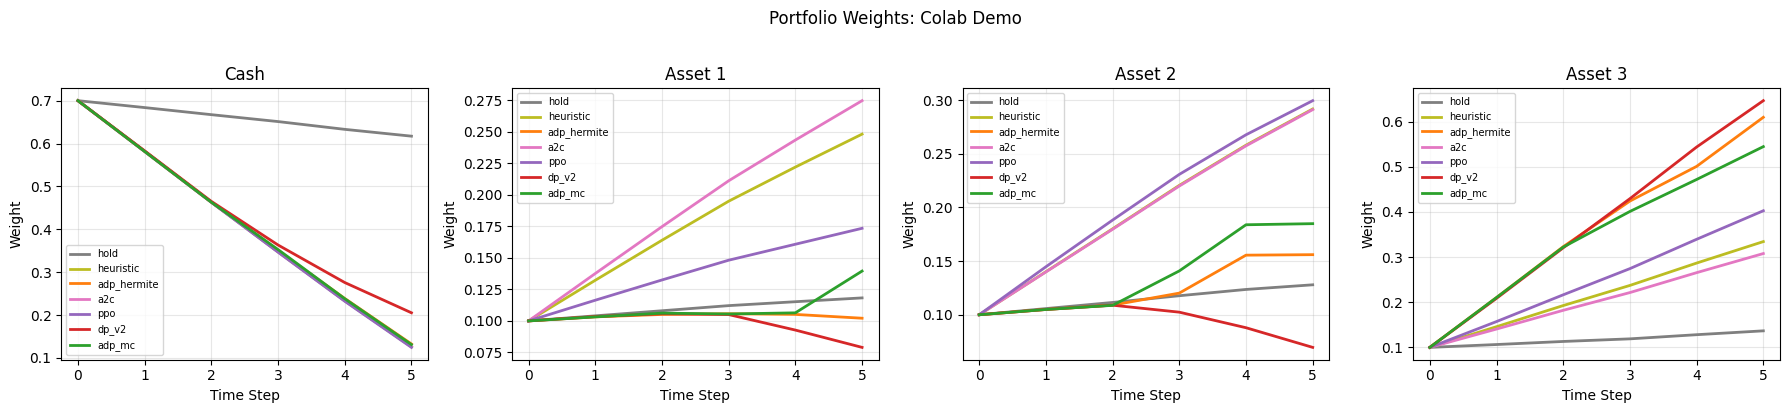

In [14]:
plot_portfolio_weights(results, config, config.name)

### 5.2 Executed Rebalancing Actions Over Time

The **actual executed deltas** at each timestep, averaged over episodes. These are the true trades after turnover projection and constraint enforcement.

  Saved: rebalancing_colab_demo.png


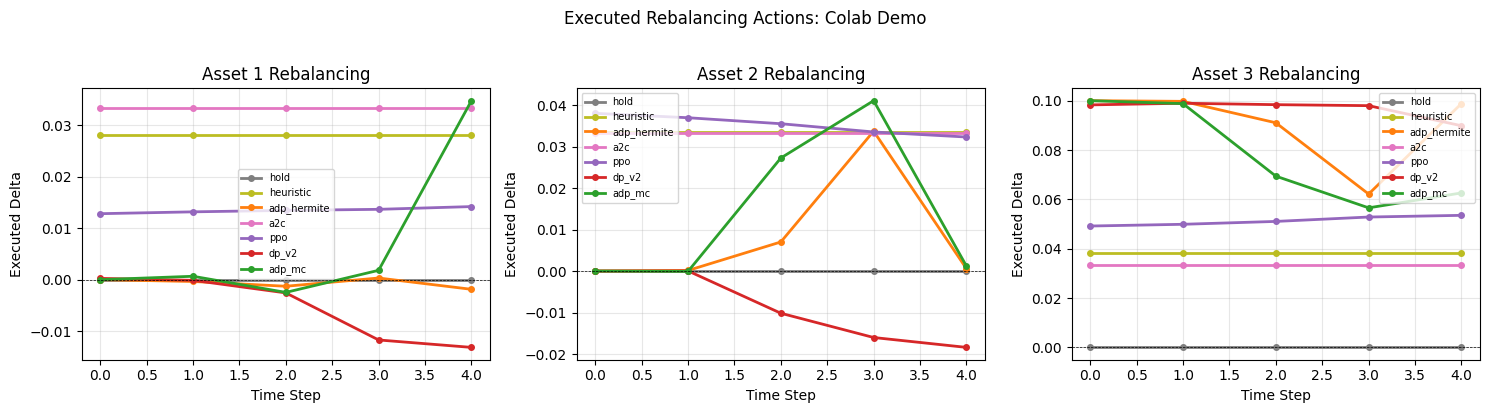

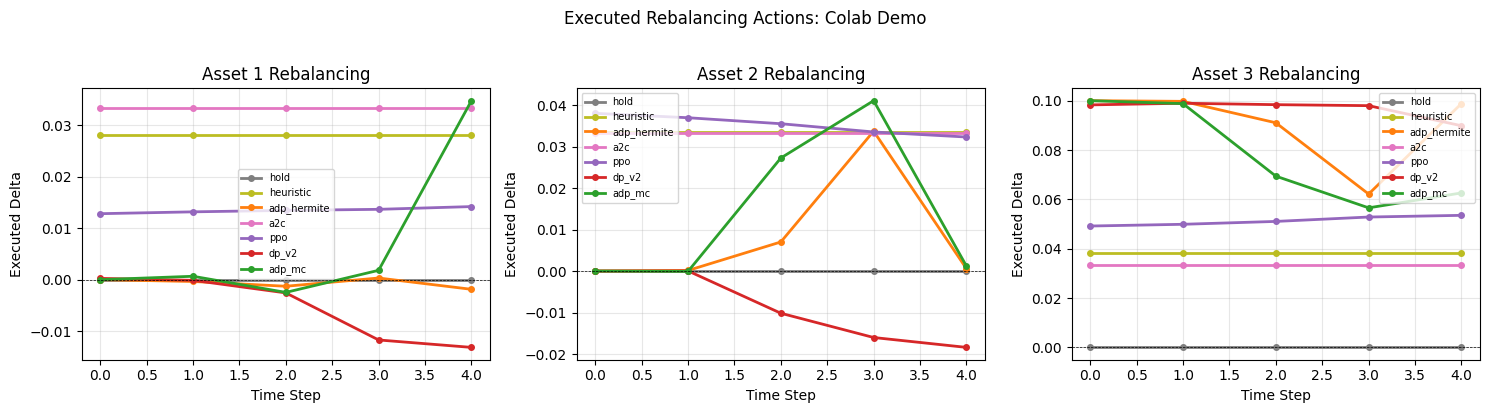

In [15]:
plot_rebalancing_actions(results, config, config.name)

### 5.3 Single Episode Trajectory

Detailed breakdown of one episode with shared returns across all methods.

  Saved: anatomy_colab_demo.png


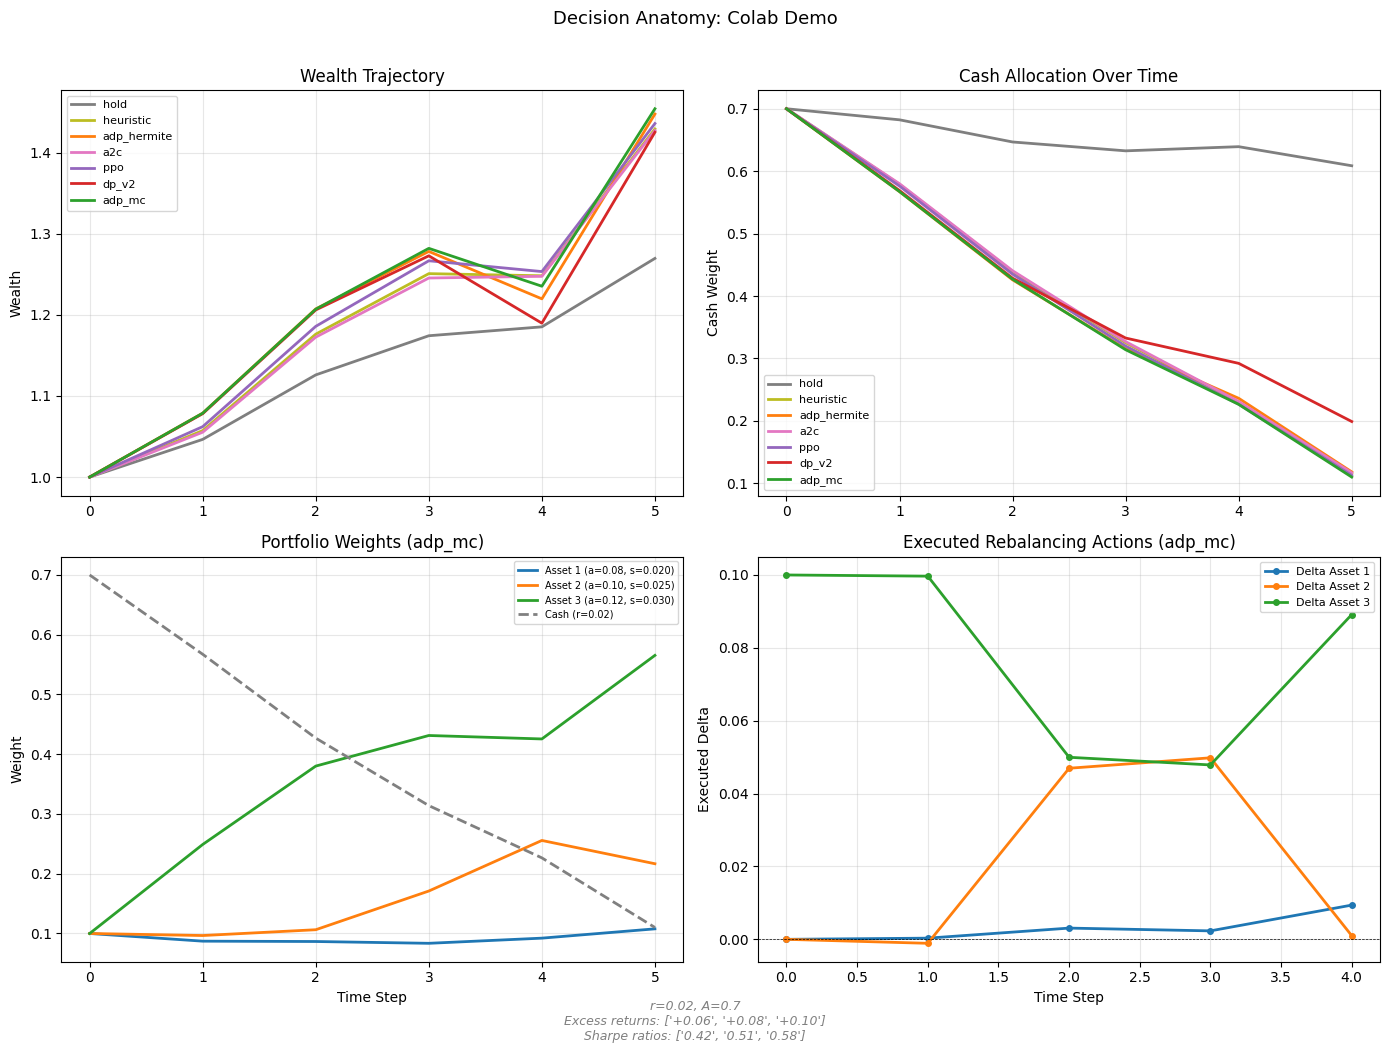

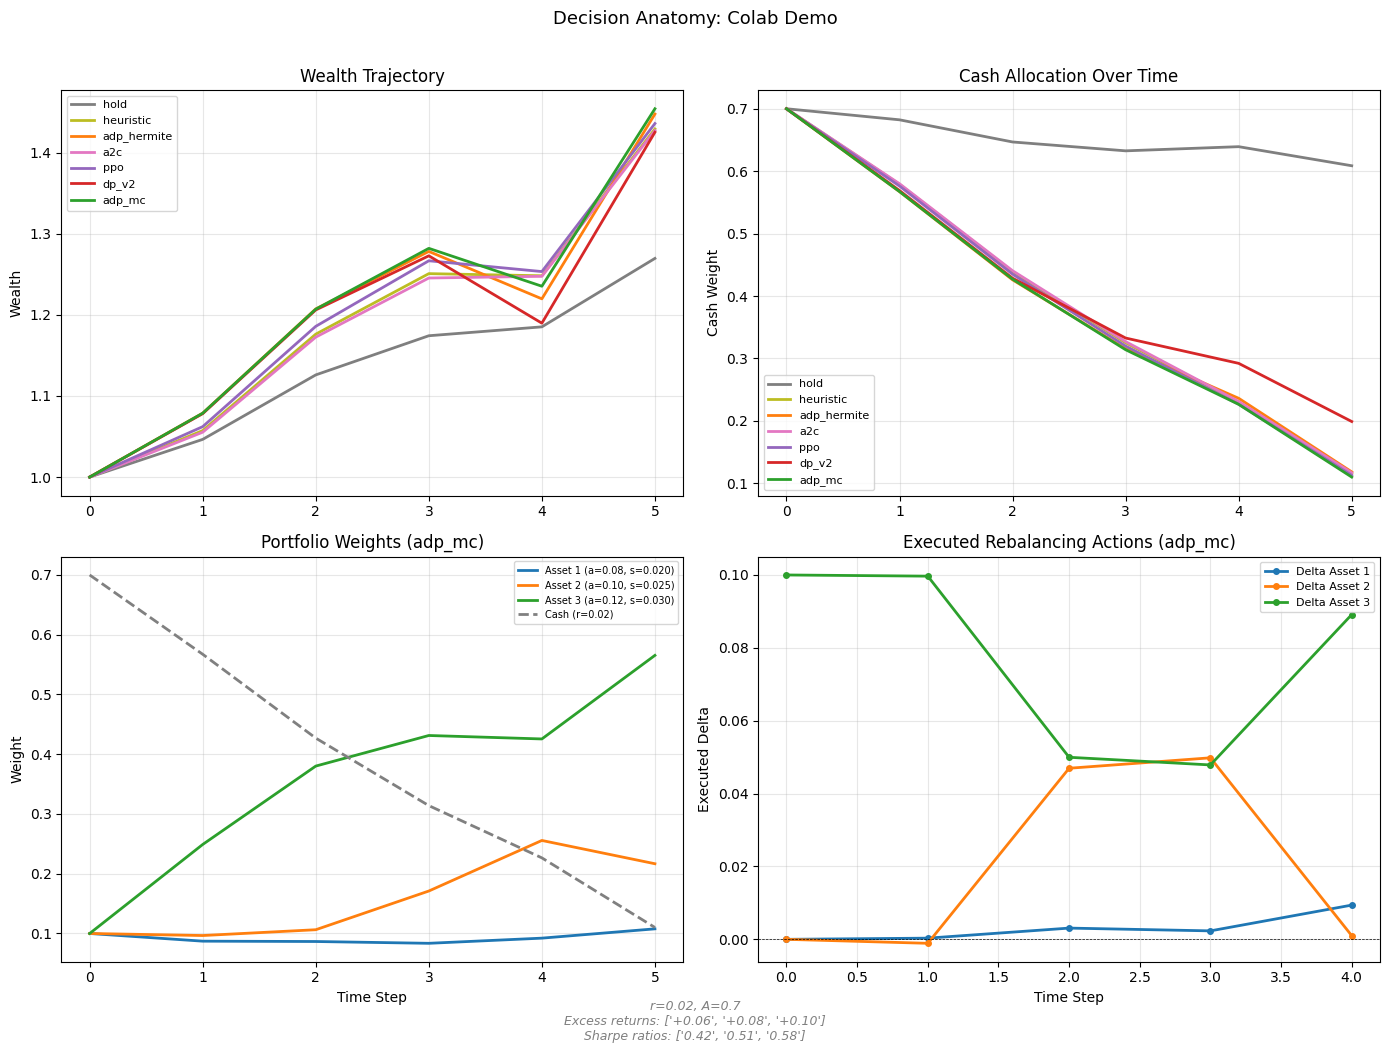

In [16]:
ep_returns = shared[0]  # first episode's returns
plot_decision_anatomy(policy_fns, config, config.name, shared_returns=ep_returns)

## 6. Economic Intuition Tests

These scenarios validate that the learned policies make economic sense. For each, we check:
- Do methods agree on the *direction* of initial rebalancing?
- Are the magnitudes consistent with risk/return trade-offs?
- Do portfolio weights evolve sensibly over time?

All deltas shown are **actual executed trades** after constraint enforcement.

In [24]:
def run_intuition_test(scenario_key, skip_tabular=False):
    """Train all methods on a scenario and produce comparison plots."""
    cfg = SCENARIOS[scenario_key]
    skip = skip_tabular or cfg.n > 3  # tabular/dp_v2 infeasible for n>3
    print(f"\n{'='*60}")
    print(f"Scenario: {cfg.summary()}")
    print(f"{'='*60}")

    pfns = {'hold': hold_policy, 'heuristic': heuristic_policy}

    if not skip:
        tab = tabular_solve(cfg)
        pfns['tabular'] = tabular_policy(tab)

    herm = hermite_solve(cfg)
    pfns['adp_hermite'] = hermite_policy(herm)

    mc = mc_solve(cfg)
    pfns['adp_mc'] = mc_policy(mc)

    if not skip:
        dpv2 = dpv2_solve(cfg)
        pfns['dp_v2'] = dpv2_policy(dpv2)

        ppo_st = ppo_solve(cfg)
        pfns['ppo'] = ppo_policy(ppo_st)

    a2c_st = a2c_solve(cfg)
    pfns['a2c'] = a2c_policy(a2c_st)

    sh = generate_shared_returns(cfg)
    res = {}
    for name, pfn in pfns.items():
        env = PortfolioEnv(cfg)
        res[name] = evaluate_policy(env, pfn, n_episodes=cfg.n_eval_episodes,
                                    seed=cfg.seed, shared_returns=sh)
        print(format_result(res[name], name))

    # Plots
    plot_economic_intuition(pfns, cfg, cfg.name)
    plot_rebalancing_actions(res, cfg, cfg.name)
    plot_portfolio_weights(res, cfg, cfg.name)
    plot_decision_anatomy(pfns, cfg, cfg.name, shared_returns=sh[0])
    return pfns, res

### 6.1 Risky Worse Than Cash -- Flee to Safety

In `long_only_risky_worse` (r=0.06, a_k=[0.01, 0.02, 0.03]), **every risky asset underperforms cash**. The Sharpe ratios are all negative. A rational investor should:
- **Move all wealth to cash** as fast as the turnover constraint allows
- **Reduce asset 1 first** (worst return: 0.01 vs r=0.06, highest negative excess)
- **Negative deltas** across the board at every time step

This is the clearest test of economic rationality — any method that doesn't flee to cash is broken.

Streaming output truncated to the last 5000 lines.
|    policy_loss        | 0.0849   |
|    std                | 0.882    |
|    value_loss         | 0.000425 |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 5        |
|    ep_rew_mean        | 0.699    |
| time/                 |          |
|    fps                | 628      |
|    iterations         | 72400    |
|    time_elapsed       | 575      |
|    total_timesteps    | 362000   |
| train/                |          |
|    entropy_loss       | -3.84    |
|    explained_variance | nan      |
|    learning_rate      | 0.0007   |
|    n_updates          | 72399    |
|    policy_loss        | 0.263    |
|    std                | 0.884    |
|    value_loss         | 0.00338  |
------------------------------------
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 5        |
|    ep_rew_mean        

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Saved: intuition_long-only_risky_worse_than_cash.png


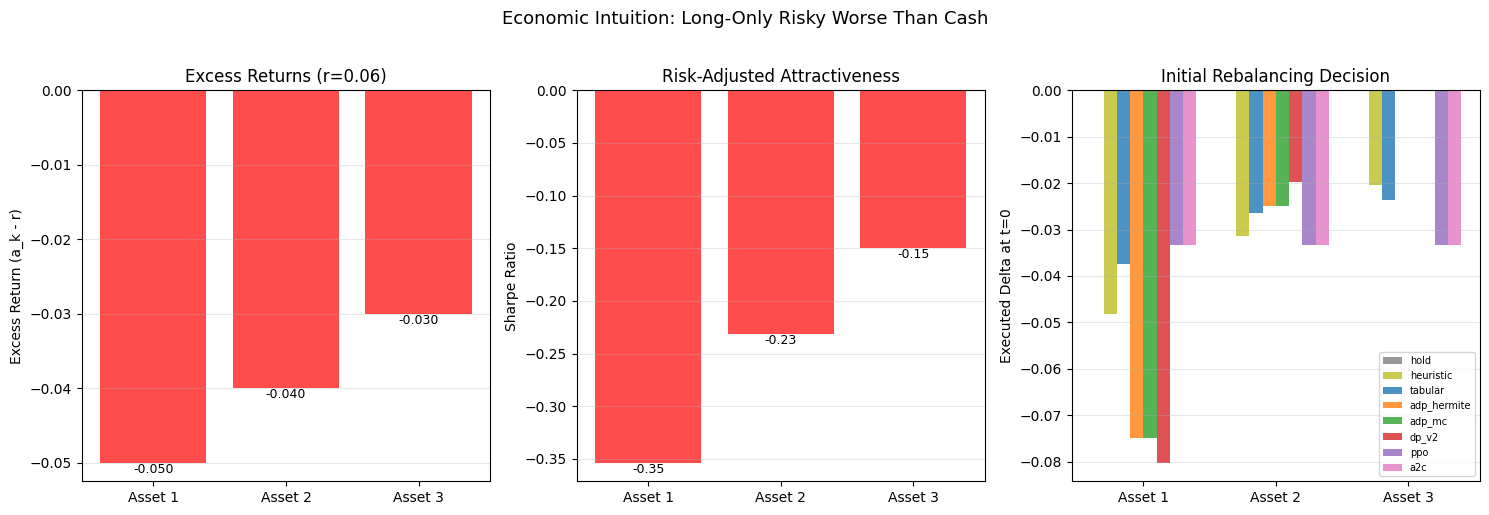

  Saved: rebalancing_long-only_risky_worse_than_cash.png


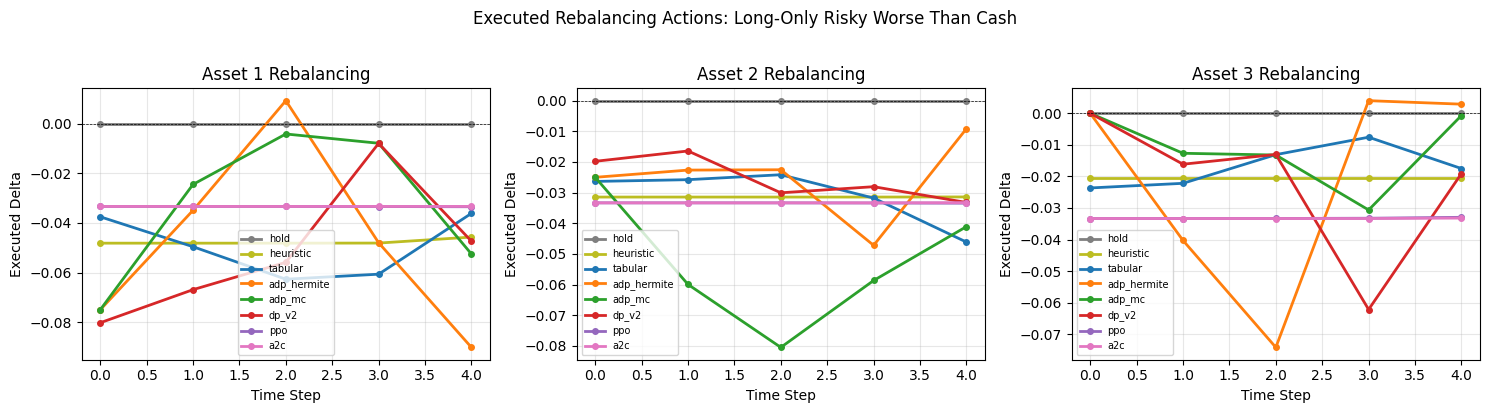

  Saved: weights_long-only_risky_worse_than_cash.png


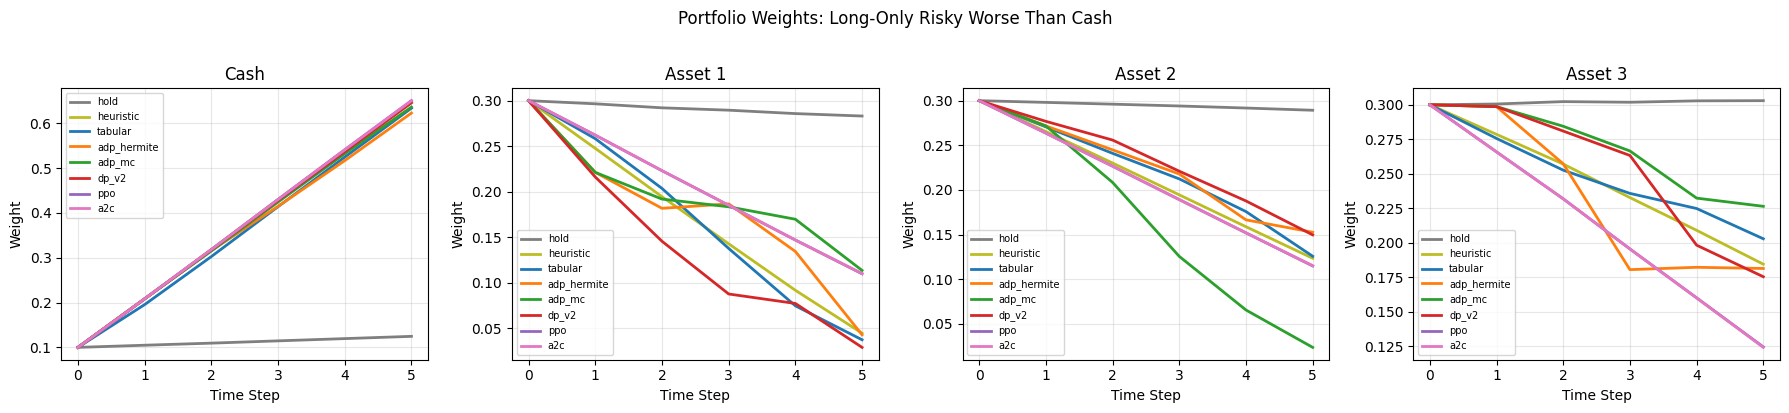

  Saved: anatomy_long-only_risky_worse_than_cash.png


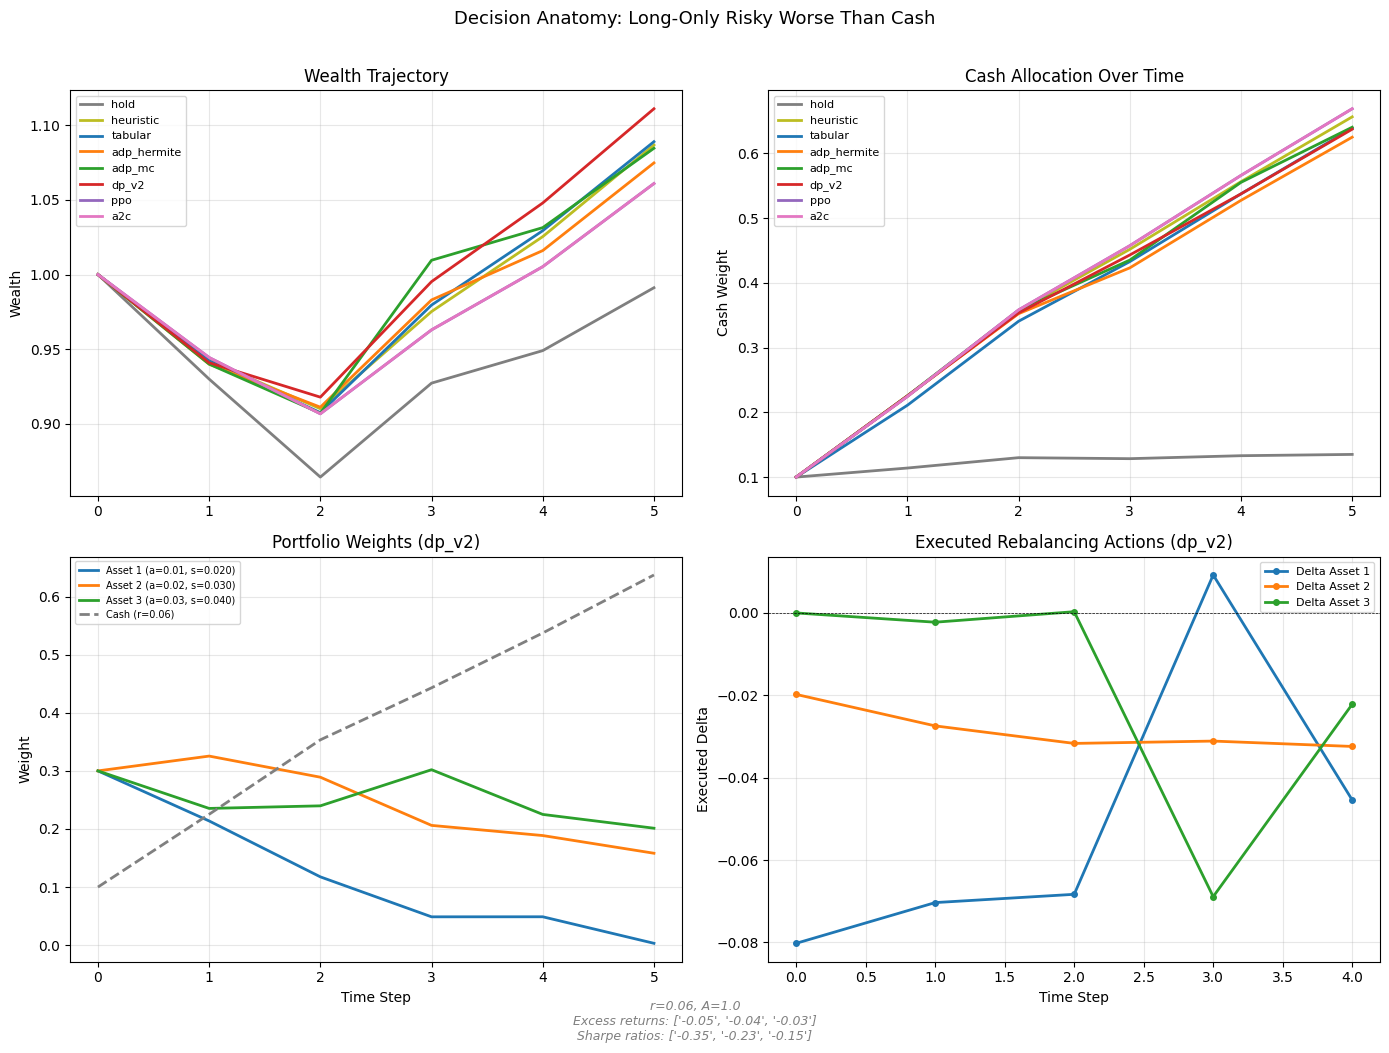

In [ ]:
pfns_rw, res_rw = run_intuition_test('long_only_risky_worse')

### 6.2 Forced Convergence Test -- Dominant Asset

Asset 3 has a dramatically higher expected return (0.20) with the same variance as others. Low risk aversion (A=0.05). All methods should aggressively buy Asset 3.

In [ ]:
pfns_fc, res_fc = run_intuition_test('forced_convergence_test')

### 6.3 High Risk Aversion -- Conservative Allocation

With A=3.0, the CARA utility penalizes wealth variance extremely heavily. Even though all risky assets have positive excess returns (a_k=[0.08, 0.10, 0.12] vs r=0.03), the optimal policy should:
- **Keep significantly more cash** than in low-A scenarios
- **Take smaller positions** in risky assets
- **Prefer lower-variance assets** (asset 1: s=0.02) over higher-return but riskier ones (asset 3: s=0.03)
- The optimal allocation is a **compromise** between return-seeking and variance-penalizing

In [ ]:
pfns_hr, res_hr = run_intuition_test('high_risk_aversion')

### 6.4 Long-Short Mixed -- Short the Loser

In `long_short_mixed` (a_k=[0.04, 0.14, -0.03], r=0.03, leverage=2.0, short allowed), asset 3 has **negative expected return** and high variance (0.04). A rational policy should:
- **Short asset 3** (negative weight) to profit from its negative expected return
- **Go long asset 2** (best risk-adjusted return: excess=0.11, Sharpe very high)
- **Use leverage** to amplify exposure to profitable assets
- The **turnover constraint** limits how fast positions can be built

In [ ]:
pfns_ls, res_ls = run_intuition_test('long_short_mixed')

### 6.5 Four Assets (n=4, T=9): Scaling Without Tabular

For n=4 assets, the tabular solver is infeasible (grid size explodes combinatorially). We rely on ADP and RL methods only. This tests whether the approximate methods **agree with each other** even without an exact ground truth.

If ADP-MC, ADP-Hermite, PPO, and A2C all converge to the same policy, we have strong evidence of optimality via the **cross-validation argument**: four algorithmically independent methods are unlikely to all converge to the same wrong answer.

In [25]:
pfns_ls, res_ls = run_intuition_test('four_assets_T9')


Scenario: 4 Assets T=9: n=4, T=9, r=0.02, A=0.7, long-only, lev=1.0
[ADP-Hermite] n=4, T=9, A=0.7, states=1000, actions=1251, quad=625

Backward Induction (ADP-Hermite)
  t=8: 1000/1000 valid, V=[0.736, 1.321], 38.3s
  t=7: 1000/1000 valid, V=[0.797, 1.365], 1731.0s


KeyboardInterrupt: 

## 7. Try Another Scenario

Change the scenario key below and re-run to compare methods on different market conditions.

Available scenarios: `long_only_attractive`, `long_only_risky_worse`, `long_only_dominant`, `long_only_symmetric`, `mixed_quality`, `high_risk_aversion`, `low_risk_aversion`, `long_short_attractive`, `long_short_mixed`, `two_assets`, `high_volatility`, `zero_rfr`, `tight_turnover`, `near_cash_asset`, `dominant_low_vol`, `balanced_assets`, `four_assets_T9`, `four_assets_T8`, `four_assets_T7`, `colab_demo`, `forced_convergence_test`

In [ ]:
pfns_other, res_other = run_intuition_test('long_only_dominant')

Scenario: Long-Only Risky Worse Than Cash: n=3, T=5, r=0.06, A=1.0, long-only, lev=1.0
Excess returns: [-0.05, -0.04, -0.03]
Initial weights: [0.1, 0.3, 0.3, 0.3]

Loading standard PPO from cache...
  [ppo] Loading from cache: ppo_long-only_risky_worse_than_cash_1ab9dfcf5e93.zip
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Loading ADP-Hermite from cache...
  [adp_hermite] Loading from cache: adp_hermite_long-only_risky_worse_than_cash_4ecd548fe84b.pt
Training augmented PPO (state includes excess returns + volatilities)...
  Done.

  heuristic               utility=0.69271 +/- 0.05004  wealth=1.19394 +/- 0.17007
  adp_hermite             utility=0.69152 +/- 0.04948  wealth=1.18953 +/- 0.16611
  ppo_standard            utility=0.69185 +/- 0.04787  wealth=1.18976 +/- 0.16100
  ppo_augmented           utility=0.69201 +/- 0.04810  wealth=1.19042 +/- 0.16193

--- Economic Intuition (initial executed deltas) ---


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


  Saved: intuition_long-only_risky_worse_than_cash_ppo_comparison.png


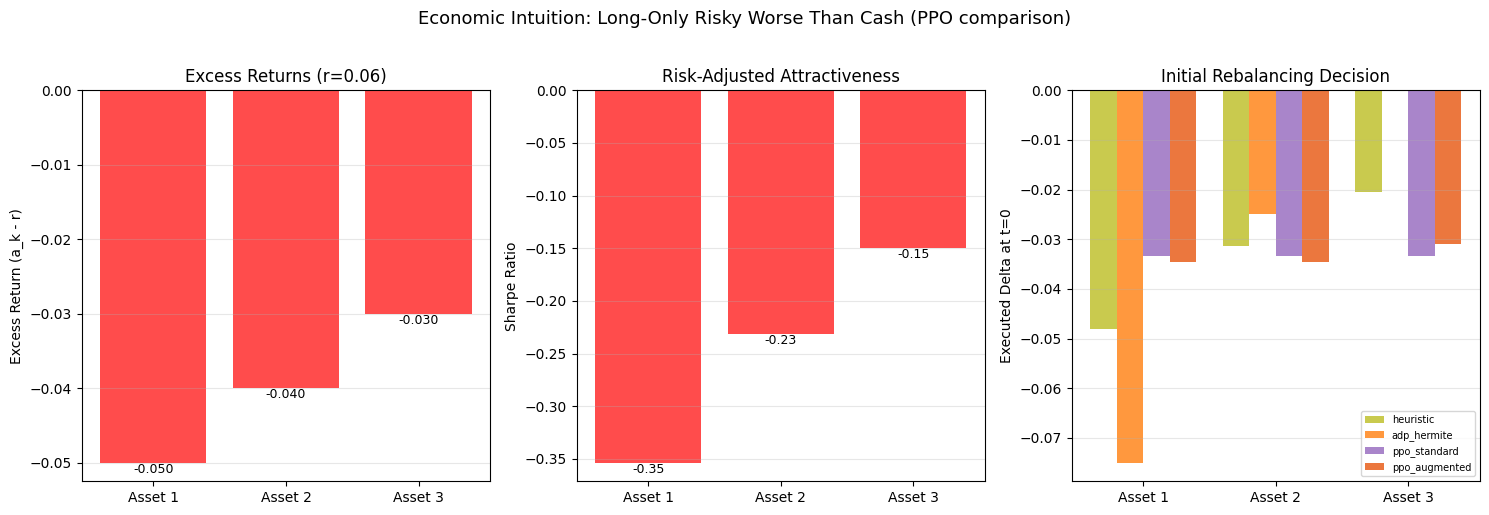


--- Rebalancing Actions Over Time ---
  Saved: rebalancing_long-only_risky_worse_than_cash_ppo_comparison.png


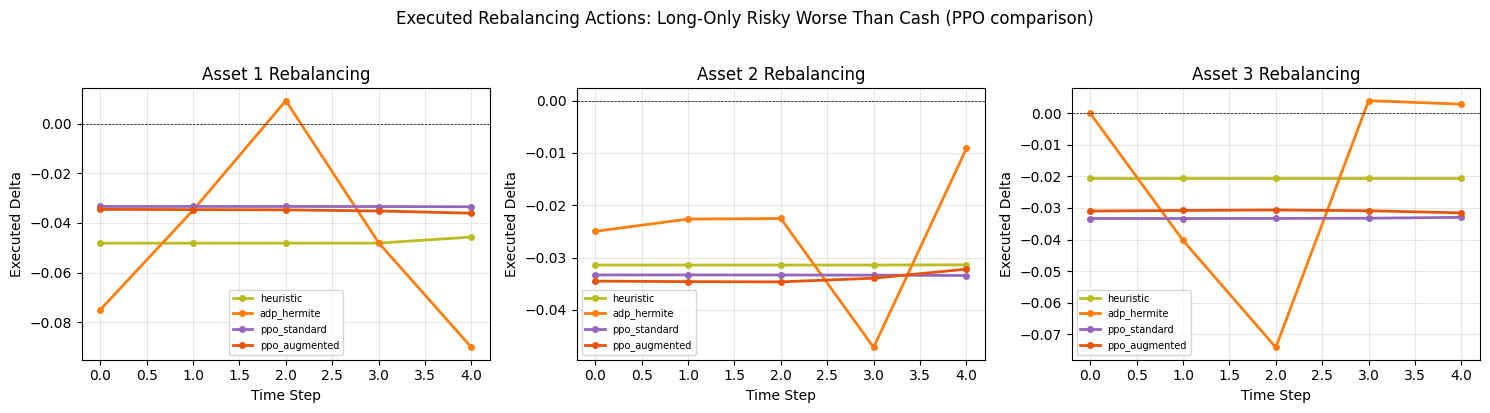


--- Portfolio Weights Over Time ---
  Saved: weights_long-only_risky_worse_than_cash_ppo_comparison.png


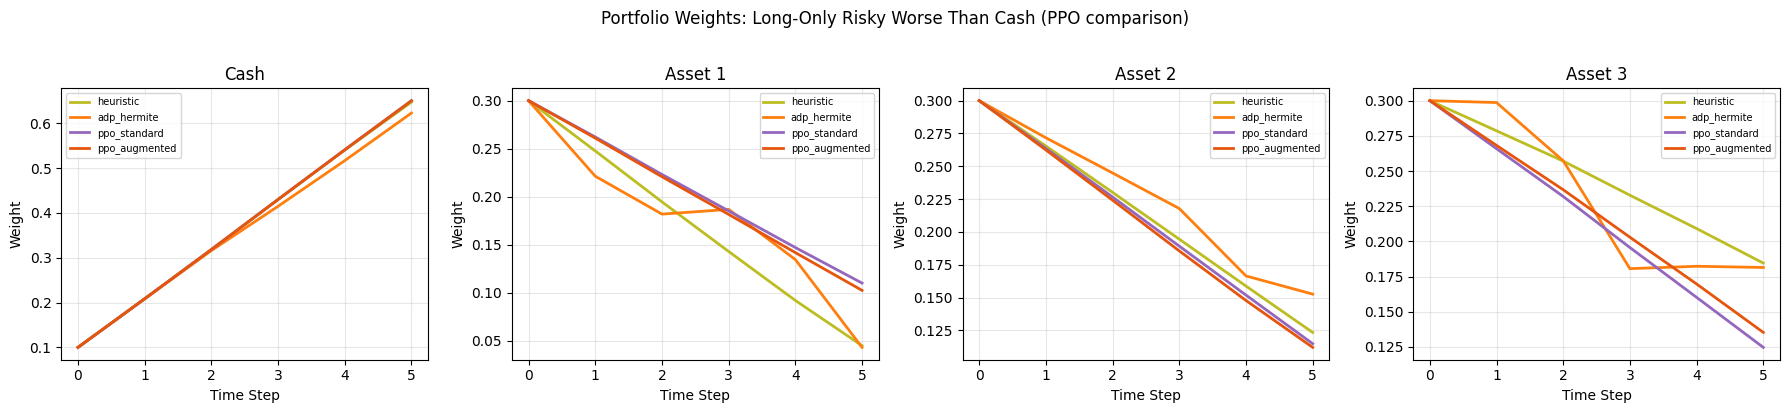

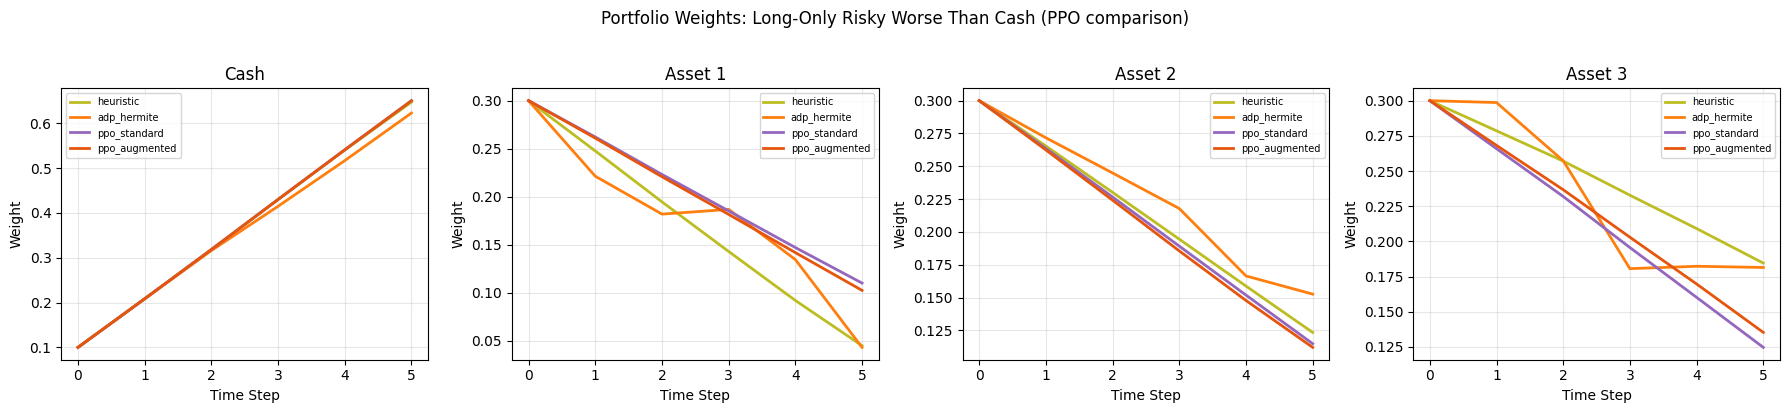

In [18]:
# === PPO with asset characteristics in observation space ===
# Test: does PPO learn asymmetric selling when it can SEE which asset is worst?

import numpy as np
import gymnasium as gym
from gymnasium import spaces
from asset_allocation.config import SCENARIOS
from asset_allocation.utils import executed_delta
from asset_allocation.environment import PortfolioEnv
from asset_allocation.evaluation import evaluate_policy, generate_shared_returns, format_result
from asset_allocation.plotting import (
    plot_economic_intuition, plot_rebalancing_actions, plot_portfolio_weights, METHOD_COLORS
)
from asset_allocation.baselines import hold_policy, heuristic_policy
from asset_allocation.ppo_solver import solve as ppo_solve, get_policy_fn as ppo_policy
from asset_allocation.adp_hermite_solver import solve as hermite_solve, get_policy_fn as hermite_policy
from stable_baselines3 import PPO


class PortfolioEnvWithCharacteristics(gym.Env):
    """Same as PortfolioEnv but observation includes asset characteristics.

    Obs: [t/T, W, p_cash, p_1..p_n, (a_1-r)..(a_n-r), sqrt(s_1)..sqrt(s_n)]
    """
    def __init__(self, config):
        super().__init__()
        self._inner = PortfolioEnv(config)
        for attr in ['n', 'T', 'r', 'A', 'a_k', 's_k', 'max_turnover',
                     'leverage_factor', 'allow_short', 'action_max', 'p_init']:
            setattr(self, attr, getattr(self._inner, attr))

        self.excess_returns = (np.array(config.a_k) - config.r).astype(np.float32)
        self.volatilities = np.sqrt(np.array(config.s_k)).astype(np.float32)

        self.action_space = self._inner.action_space
        obs_dim = self.n + 3 + 2 * self.n
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(obs_dim,), dtype=np.float32)

    def _augment_obs(self, obs):
        return np.concatenate([obs, self.excess_returns, self.volatilities])

    def reset(self, seed=None, options=None):
        obs, info = self._inner.reset(seed=seed, options=options)
        self.t = self._inner.t
        self.wealth = self._inner.wealth
        self.p = self._inner.p
        return self._augment_obs(obs), info

    def step(self, action):
        obs, reward, done, trunc, info = self._inner.step(action)
        self.t = self._inner.t
        self.wealth = self._inner.wealth
        self.p = self._inner.p
        return self._augment_obs(obs), reward, done, trunc, info


cfg = SCENARIOS['long_only_risky_worse']
print(f"Scenario: {cfg.summary()}")
print(f"Excess returns: {[round(a - cfg.r, 3) for a in cfg.a_k]}")
print(f"Initial weights: {cfg.p_init}\n")

# 1) Standard PPO -- load from cache
print("Loading standard PPO from cache...")
ppo_state = ppo_solve(cfg)
ppo_std_fn = ppo_policy(ppo_state)

# 2) ADP-Hermite -- load from cache
print("Loading ADP-Hermite from cache...")
herm_state = hermite_solve(cfg)
herm_fn = hermite_policy(herm_state)

# 3) Augmented PPO -- train fresh (no cache for this custom env)
print("Training augmented PPO (state includes excess returns + volatilities)...")
env_aug = PortfolioEnvWithCharacteristics(cfg)
model_aug = PPO("MlpPolicy", env_aug, learning_rate=1e-3, gamma=1.0,
                n_steps=2048, batch_size=64, seed=cfg.seed, device="cpu", verbose=0)
model_aug.learn(total_timesteps=500_000)
print("  Done.\n")

def ppo_aug_policy(obs, env):
    excess = (np.array(cfg.a_k) - cfg.r).astype(np.float32)
    vols = np.sqrt(np.array(cfg.s_k)).astype(np.float32)
    aug_obs = np.concatenate([obs, excess, vols])
    action, _ = model_aug.predict(aug_obs, deterministic=True)
    return np.clip(action, -1.0, 1.0).astype(np.float32)

policy_fns = {
    'heuristic': heuristic_policy,
    'adp_hermite': herm_fn,
    'ppo_standard': ppo_std_fn,
    'ppo_augmented': ppo_aug_policy,
}

# --- Evaluate ---
shared = generate_shared_returns(cfg)
results = {}
for name, pfn in policy_fns.items():
    env = PortfolioEnv(cfg)
    results[name] = evaluate_policy(env, pfn, n_episodes=cfg.n_eval_episodes,
                                    seed=cfg.seed, shared_returns=shared)
    print(format_result(results[name], name))

# --- Plots ---
METHOD_COLORS['ppo_standard'] = '#9467bd'
METHOD_COLORS['ppo_augmented'] = '#e6550d'

print("\n--- Economic Intuition (initial executed deltas) ---")
plot_economic_intuition(policy_fns, cfg, cfg.name + " (PPO comparison)")

print("\n--- Rebalancing Actions Over Time ---")
plot_rebalancing_actions(results, cfg, cfg.name + " (PPO comparison)")

print("\n--- Portfolio Weights Over Time ---")
plot_portfolio_weights(results, cfg, cfg.name + " (PPO comparison)")

